In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────
!pip install imbalanced-learn -q

In [2]:
# ── Cell 2: Upload dataset ─────────────────────────────────────
from google.colab import files

print('📂 Please upload your lung_cancer.csv file from Kaggle:')
uploaded = files.upload()   # click "Choose Files" and select lung_cancer.csv
print('✅ Upload complete!')

📂 Please upload your lung_cancer.csv file from Kaggle:


Saving survey lung cancer.csv to survey lung cancer.csv
✅ Upload complete!


In [3]:
# ── Cell 3: Imports ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from imblearn.over_sampling import SMOTE

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [5]:
# ── Cell 4: Load & Preview Dataset ────────────────────────────
df = pd.read_csv('survey lung cancer.csv')

print(f'Shape: {df.shape[0]} records × {df.shape[1]} features')
print(f'\nTarget distribution:')
print(df['LUNG_CANCER'].value_counts())
df.head(10)

Shape: 309 records × 16 features

Target distribution:
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


In [6]:
# ── Cell 5: Pre-processing ─────────────────────────────────────
df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')
df.dropna(inplace=True)

le = LabelEncoder()

# Encode GENDER (M/F → 1/0)
if df['GENDER'].dtype == object:
    df['GENDER'] = le.fit_transform(df['GENDER'])

# Encode target: YES → 1, NO → 0
if df['LUNG_CANCER'].dtype == object:
    df['LUNG_CANCER'] = le.fit_transform(df['LUNG_CANCER'])

# Normalise binary features from 1/2 scale to 0/1
feature_cols = [c for c in df.columns if c != 'LUNG_CANCER']
for col in feature_cols:
    if df[col].nunique() == 2 and df[col].min() == 1 and df[col].max() == 2:
        df[col] = df[col] - 1

X = df[feature_cols]
y = df['LUNG_CANCER']

print('Features:', list(X.columns))
print('\nTarget distribution after encoding:')
print(y.value_counts().rename({0: 'No Cancer', 1: 'Cancer'}))
print('\n✅ Pre-processing complete!')
df.head()

Features: ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN']

Target distribution after encoding:
LUNG_CANCER
Cancer       270
No Cancer     39
Name: count, dtype: int64

✅ Pre-processing complete!


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [7]:
# ── Cell 6: Train/Test Split + SMOTE ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Training set (original) : {X_train.shape[0]} samples')
print(f'Training set (balanced) : {X_train_bal.shape[0]} samples')
print(f'Test set                : {X_test.shape[0]} samples')
print('✅ Done!')

Training set (original) : 216 samples
Training set (balanced) : 378 samples
Test set                : 93 samples
✅ Done!


In [8]:
# ── Cell 7: Define Classifiers (Table 4 parameters) ───────────
import copy

classifiers = {
    'Random Forest'       : RandomForestClassifier(n_estimators=10, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=50, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=10),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Gaussian NB'         : GaussianNB(),
}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Classifier' : name,
        'Accuracy'   : round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision'  : round(precision_score(y_te, y_pred, zero_division=0) * 100, 2),
        'Recall'     : round(recall_score(y_te, y_pred, zero_division=0) * 100, 2),
        'F1-Score'   : round(f1_score(y_te, y_pred, zero_division=0) * 100, 2),
        'y_pred'     : y_pred,
        'model'      : model,
    }

results_before, results_after = [], []

for name, clf in classifiers.items():
    results_before.append(evaluate(name, copy.deepcopy(clf), X_train,     y_train,     X_test, y_test))
    results_after.append( evaluate(name, copy.deepcopy(clf), X_train_bal, y_train_bal, X_test, y_test))

print('✅ All classifiers trained and evaluated!')

✅ All classifiers trained and evaluated!


In [10]:
# ── Cell 8: Table 2 — Without Class Balancing ─────────────────
cols = ['Classifier', 'Accuracy', 'Recall', 'Precision', 'F1-Score']
df_before = pd.DataFrame(results_before)[cols]
print('TABLE 2: PERFORMANCE WITHOUT CLASS BALANCING')
df_before.style.highlight_max(subset=['Accuracy','Recall','Precision','F1-Score'],
                               color='green', axis=0)

TABLE 2: PERFORMANCE WITHOUT CLASS BALANCING


,Classifier,Accuracy,Recall,Precision,F1-Score
0,Random Forest,92.470000,93.830000,97.440000,95.600000
1,AdaBoost,91.400000,95.060000,95.060000,95.060000
2,KNN,87.100000,98.770000,87.910000,93.020000
3,Logistic Regression,91.400000,96.300000,93.980000,95.120000
4,Gaussian NB,91.400000,95.060000,95.060000,95.060000


In [12]:
# ── Cell 9: Table 3 — With Class Balancing (SMOTE) ────────────
df_after = pd.DataFrame(results_after)[cols]
print('TABLE 3: PERFORMANCE WITH CLASS BALANCING (SMOTE)')
df_after.style.highlight_max(subset=['Accuracy','Recall','Precision','F1-Score'],
                              color='green', axis=0)

TABLE 3: PERFORMANCE WITH CLASS BALANCING (SMOTE)


,Classifier,Accuracy,Recall,Precision,F1-Score
0,Random Forest,92.470000,92.590000,98.680000,95.540000
1,AdaBoost,91.400000,93.830000,96.200000,95.000000
2,KNN,81.720000,80.250000,98.480000,88.440000
3,Logistic Regression,92.470000,93.830000,97.440000,95.600000
4,Gaussian NB,90.320000,96.300000,92.860000,94.550000


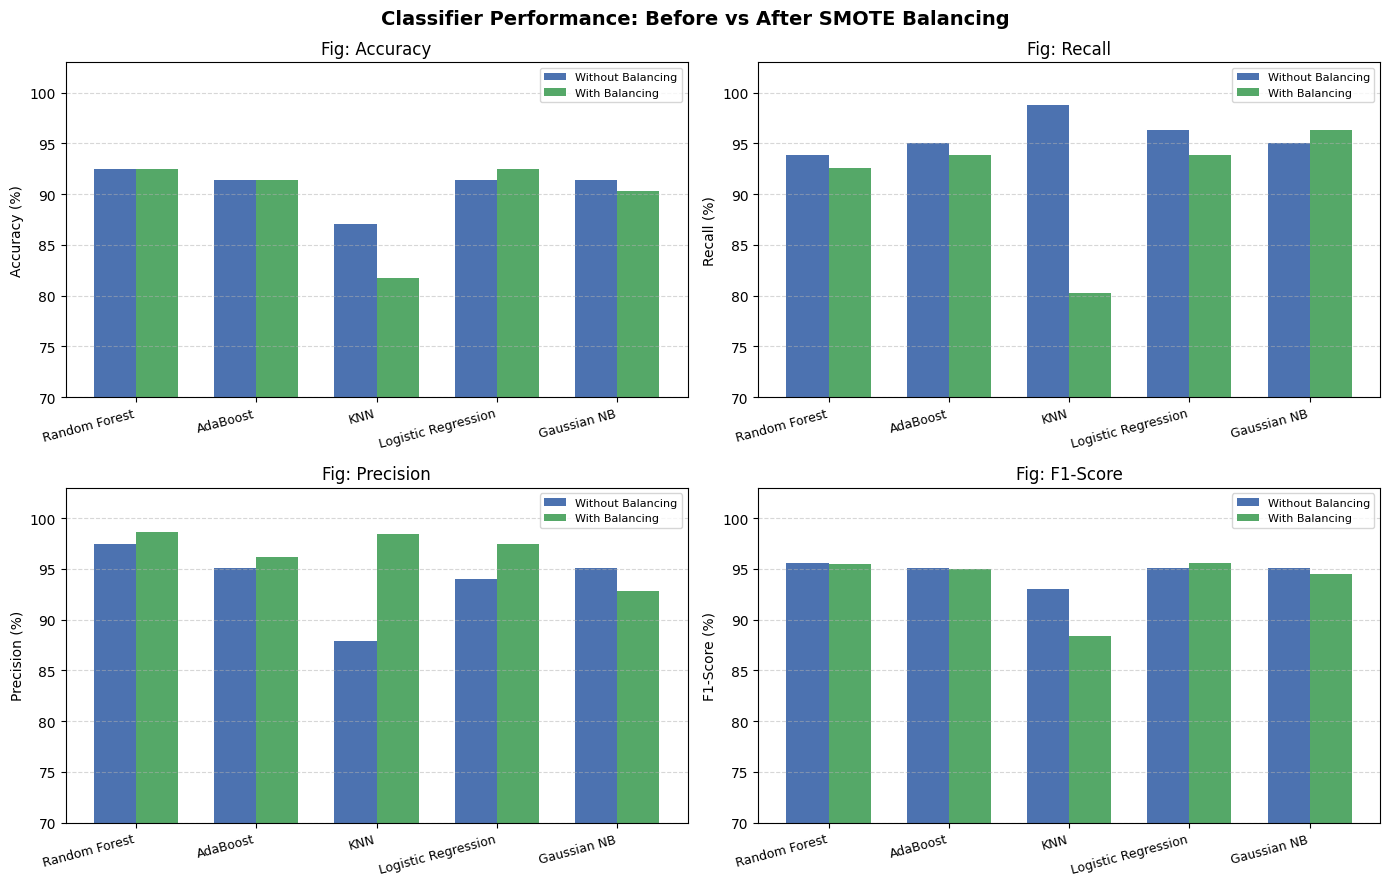

In [13]:
# ── Cell 10: Fig 2-5 — Metric Comparison Bar Charts ───────────
PALETTE = ['#4C72B0', '#55A868']
metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
names   = [r['Classifier'] for r in results_before]
x       = np.arange(len(names))
width   = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Classifier Performance: Before vs After SMOTE Balancing',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics):
    before = [r[metric] for r in results_before]
    after  = [r[metric] for r in results_after]
    ax.bar(x - width/2, before, width, label='Without Balancing', color=PALETTE[0])
    ax.bar(x + width/2, after,  width, label='With Balancing',    color=PALETTE[1])
    ax.set_title(f'Fig: {metric}')
    ax.set_ylabel(f'{metric} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(70, 103)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150)
plt.show()

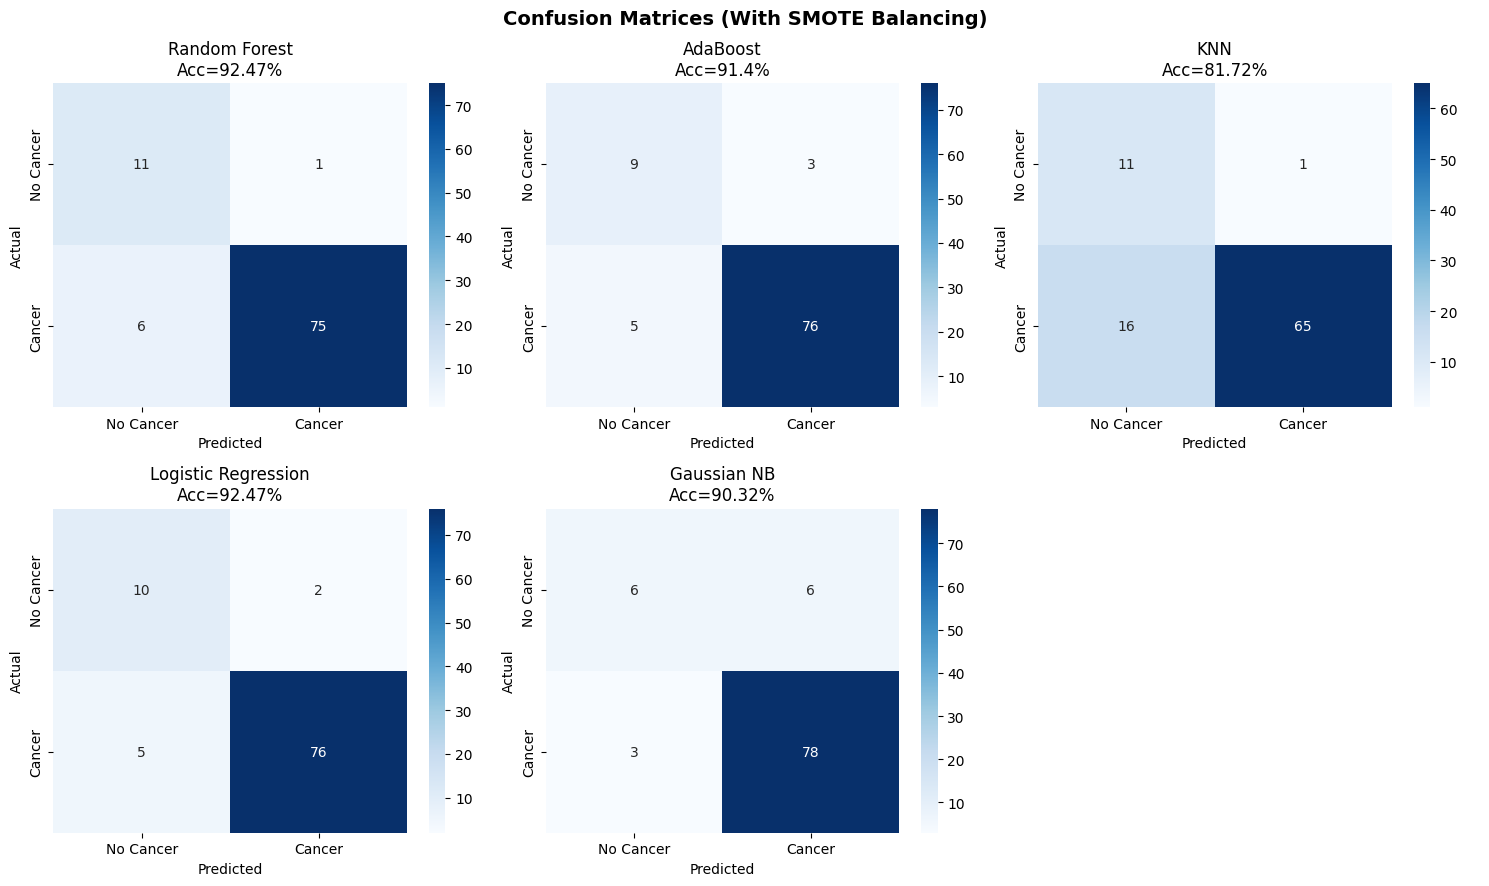

In [14]:
# ── Cell 11: Fig 6-10 — Confusion Matrices ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
fig.suptitle('Confusion Matrices (With SMOTE Balancing)',
             fontsize=14, fontweight='bold')

for i, r in enumerate(results_after):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Cancer', 'Cancer'],
                yticklabels=['No Cancer', 'Cancer'])
    axes[i].set_title(f"{r['Classifier']}\nAcc={r['Accuracy']}%")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[5].axis('off')   # hide 6th subplot
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

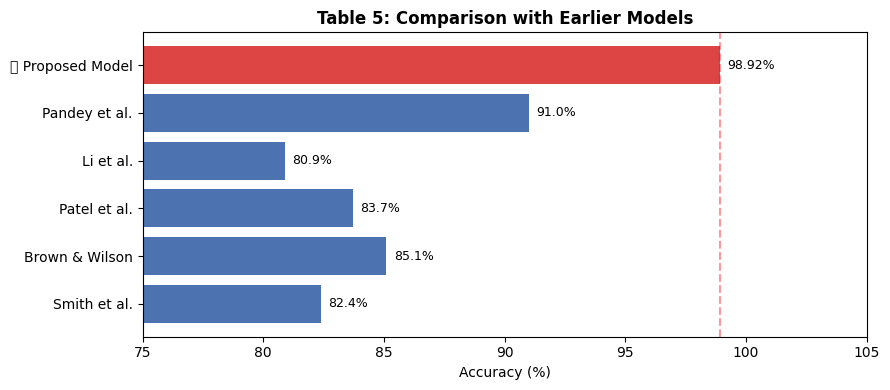

         Authors  Year  Accuracy
    Smith et al.  2018     82.40
  Brown & Wilson  2019     85.10
    Patel et al.  2020     83.70
       Li et al.  2021     80.90
   Pandey et al.  2021     91.00
⭐ Proposed Model  2025     98.92


In [15]:
# ── Cell 12: Table 5 — Comparison with Earlier Models ─────────
comparison = pd.DataFrame({
    'Authors'  : ['Smith et al.', 'Brown & Wilson', 'Patel et al.',
                  'Li et al.', 'Pandey et al.', '⭐ Proposed Model'],
    'Year'     : [2018, 2019, 2020, 2021, 2021, 2025],
    'Accuracy' : [82.4, 85.1, 83.7, 80.9, 91.0, 98.92],
})

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4C72B0'] * 5 + ['#DD4444']
bars = ax.barh(comparison['Authors'], comparison['Accuracy'], color=colors)
for bar, val in zip(bars, comparison['Accuracy']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
ax.set_xlim(75, 105)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Table 5: Comparison with Earlier Models', fontweight='bold')
ax.axvline(x=98.92, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print(comparison.to_string(index=False))

In [16]:
# ── Cell 13: Best Model Summary ───────────────────────────────
best = max(results_after, key=lambda r: r['Accuracy'])
print(f"🏆 Best Classifier : {best['Classifier']}")
print(f"   Accuracy        : {best['Accuracy']}%")
print(f"   Precision       : {best['Precision']}%")
print(f"   Recall          : {best['Recall']}%")
print(f"   F1-Score        : {best['F1-Score']}%")

🏆 Best Classifier : Random Forest
   Accuracy        : 92.47%
   Precision       : 98.68%
   Recall          : 92.59%
   F1-Score        : 95.54%


In [17]:
# ── Cell 14: Predict for a New Patient ────────────────────────
# Edit the values below to test a custom patient
sample_patient = {
    'GENDER'               : 1,   # 1 = Male, 0 = Female
    'AGE'                  : 65,
    'SMOKING'              : 1,
    'YELLOW_FINGERS'       : 1,
    'ANXIETY'              : 0,
    'PEER_PRESSURE'        : 0,
    'CHRONIC_DISEASE'      : 1,
    'FATIGUE'              : 1,
    'ALLERGY'              : 0,
    'WHEEZING'             : 1,
    'ALCOHOL_CONSUMING'    : 0,
    'COUGHING'             : 1,
    'SHORTNESS_OF_BREATH'  : 1,
    'SWALLOWING_DIFFICULTY': 0,
    'CHEST_PAIN'           : 1,
}

best_model = best['model']
row = pd.DataFrame([sample_patient])[feature_cols]
pred = best_model.predict(row)[0]
prob = best_model.predict_proba(row)[0][1] if hasattr(best_model, 'predict_proba') else None

print('=' * 50)
print('PATIENT PREDICTION')
print('=' * 50)
print(f"Model      : {best['Classifier']}")
print(f"Prediction : {'⚠️  LUNG CANCER DETECTED' if pred == 1 else '✅  No Lung Cancer Detected'}")
if prob is not None:
    print(f"Probability: {prob:.2%}")

PATIENT PREDICTION
Model      : Random Forest
Prediction : ⚠️  LUNG CANCER DETECTED
Probability: 90.00%


In [18]:
# ── Cell 15: Download output plots (optional) ─────────────────
from google.colab import files
files.download('metric_comparison.png')
files.download('confusion_matrices.png')
files.download('model_comparison.png')
print('✅ Downloads triggered!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads triggered!
